In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.decomposition import PCA
warnings.filterwarnings("ignore")

In [2]:
dataset_path = os.path.realpath(
    os.path.join(
        os.getcwd(),
        "..",
        "Radar",
        "C3"
    )
)

emotions = {
    "E01": "focus",
    "E02": "distraction",
    "E03": "stress",
    "E04": "relaxation",
    "E05": "depression",
    "E06": "excitement"
}

#### Feature extraction helpers

In [3]:
def compute_trajectory_features(xyz, speed):
    trajectory_length = np.sum(speed)

    displacement = np.linalg.norm(xyz[-1] - xyz[0])

    path_efficiency = (
        displacement / trajectory_length
        if trajectory_length > 1e-6 else 0
    )

    mins = np.min(xyz, axis=0)
    maxs = np.max(xyz, axis=0)

    bounding_box_volume = np.prod(maxs - mins)

    return trajectory_length, displacement, path_efficiency, bounding_box_volume

In [4]:
def compute_motion_features(xyz):
    if len(xyz) >= 3:

        pca = PCA(n_components=3)
        pca.fit(xyz)

        movement_anisotropy = pca.explained_variance_ratio_[0]

    else:
        movement_anisotropy = 0

    return movement_anisotropy

In [5]:
def compute_turning_features(velocity_vectors):

    if len(velocity_vectors) >= 2:

        v1 = velocity_vectors[:-1]
        v2 = velocity_vectors[1:]

        norms1 = np.linalg.norm(v1, axis=1)
        norms2 = np.linalg.norm(v2, axis=1)

        valid = (norms1 > 1e-6) & (norms2 > 1e-6)

        if np.sum(valid) > 0:

            v1 = v1[valid]
            v2 = v2[valid]

            norms1 = norms1[valid]
            norms2 = norms2[valid]

            cos_angles = np.sum(v1 * v2, axis=1)

            cos_angles /= (norms1 * norms2)

            cos_angles = np.clip(cos_angles, -1, 1)

            angles = np.arccos(cos_angles)

            mean_turning_angle = np.mean(angles)

        else:
            mean_turning_angle = 0

    else:
        mean_turning_angle = 0

    return mean_turning_angle

In [6]:
def compute_motion_bursts(speed):

    threshold = np.mean(speed) + np.std(speed)

    active = speed > threshold

    motion_bursts = np.sum(
        np.diff(active.astype(int)) == 1
    )

    return motion_bursts

In [7]:
def compute_spectral_features(speed):
    spectrum = np.abs(np.fft.rfft(speed))

    freqs = np.fft.rfftfreq(len(speed))

    if len(spectrum) > 1:

        dominant_frequency = freqs[
            np.argmax(spectrum[1:]) + 1
        ]

        spectral_centroid = (
            np.sum(freqs * spectrum)
            / (np.sum(spectrum) + 1e-12)
        )

        psd = spectrum**2
        psd /= np.sum(psd) + 1e-12

        spectral_entropy = -np.sum(
            psd * np.log(psd + 1e-12)
        )

    else:

        dominant_frequency = 0
        spectral_centroid = 0
        spectral_entropy = 0

    return dominant_frequency, spectral_centroid, spectral_entropy

In [8]:
def distribution_features(signal):
    return [
        np.mean(signal),
        np.std(signal),
        np.median(signal),
        np.percentile(signal, 25),
        np.percentile(signal, 75)
    ]

In [9]:
from scipy.stats import skew, kurtosis, entropy

def tortuosity(xyz):
    path_length = np.sum(np.linalg.norm(np.diff(xyz, axis=0), axis=1))

    displacement = np.linalg.norm(xyz[-1] - xyz[0])

    if displacement == 0:
        return 1.0

    return path_length / displacement


def curvature(velocity, accel):
    v = velocity
    a = accel

    v = v[:-1]

    cross = np.linalg.norm(np.cross(v, a), axis=1)
    speed_mag = np.linalg.norm(v, axis=1)

    denom = speed_mag ** 3

    kappa = np.divide(
        cross,
        denom,
        out=np.zeros_like(cross),
        where=denom > 1e-8
    )

    return kappa


def curvature_features(velocity, accel):
    k = curvature(velocity, accel)
    
    return {
        "mean_curvature": np.mean(k),
        "median_curvature": np.median(k),
        "std_curvature": np.std(k),
        "curvature_entropy":
            entropy(np.histogram(k, bins=10)[0] + 1)
    }

def speed_shape_features(speed):
    s = speed

    return {
        "speed_skewness": skew(s),
        "speed_kurtosis": kurtosis(s)
    }

def acceleration_shape_features(accel):
    a = np.linalg.norm(accel, axis=1)

    return {
        "acc_skewness": skew(a),
        "acc_kurtosis": kurtosis(a)
    }

def jerk_shape_features(jerk):
    j = np.linalg.norm(jerk, axis=1)

    return {
        "jerk_skewness": skew(j),
        "jerk_kurtosis": kurtosis(j)
    }

from scipy.signal import welch

def spectral_energy_features(speed, fs=1.0):
    s = speed

    f, pxx = welch(s, fs=fs)

    total = np.sum(pxx)

    if total == 0:
        return {
            "dominant_frequency": 0,
            "low_freq_ratio": 0,
            "mid_freq_ratio": 0,
            "high_freq_ratio": 0
        }

    low = np.sum(pxx[f < 0.5])
    mid = np.sum(pxx[(f >= 0.5) & (f < 1.5)])
    high = np.sum(pxx[f >= 1.5])

    return {
        "dominant_frequency": f[np.argmax(pxx)],
        "low_freq_ratio": low / total,
        "mid_freq_ratio": mid / total,
        "high_freq_ratio": high / total
    }

def pause_features(speed, threshold=None):

    s = speed

    if threshold is None:
        threshold = 0.1 * np.median(s)

    paused = s < threshold

    runs = []
    current = 0

    for p in paused:
        if p:
            current += 1
        elif current > 0:
            runs.append(current)
            current = 0

    if current > 0:
        runs.append(current)

    return {
        "pause_count": len(runs),
        "mean_pause_duration":
            np.mean(runs) if runs else 0,
        "pause_duration_cv":
            np.std(runs) / np.mean(runs)
            if len(runs) > 1 else 0,
        "fraction_stationary_time":
            np.mean(paused)
    }

def burst_features(speed):

    s = speed

    threshold = np.median(s) + np.std(s)

    bursts = s > threshold

    runs = []
    current = 0

    for b in bursts:
        if b:
            current += 1
        elif current > 0:
            runs.append(current)
            current = 0

    if current > 0:
        runs.append(current)

    return {
        "burst_count": len(runs),
        "mean_burst_duration":
            np.mean(runs) if runs else 0,
        "burst_duration_cv":
            np.std(runs) / np.mean(runs)
            if len(runs) > 1 else 0
    }

def turning_features(velocity):

    v = velocity

    angles = []

    for i in range(len(v) - 1):

        a = v[i]
        b = v[i + 1]

        na = np.linalg.norm(a)
        nb = np.linalg.norm(b)

        if na == 0 or nb == 0:
            continue

        cos_theta = np.clip(
            np.dot(a, b) / (na * nb),
            -1,
            1
        )

        angles.append(np.degrees(np.arccos(cos_theta)))

    angles = np.array(angles)

    return {
        "mean_turn_angle": np.mean(angles),
        "std_turn_angle": np.std(angles),
        "turn_angle_entropy":
            entropy(np.histogram(angles, bins=10)[0] + 1),
        "large_turn_fraction":
            np.mean(angles > 45)
    }


def axis_coordination_features(xyz):

    x = xyz[:, 0]
    y = xyz[:, 1]
    z = xyz[:, 2]

    return {
        "corr_xy": np.corrcoef(x, y)[0, 1],
        "corr_xz": np.corrcoef(x, z)[0, 1],
        "corr_yz": np.corrcoef(y, z)[0, 1]
    }

def pca_features(xyz):

    pca = PCA(n_components=3)
    pca.fit(xyz)

    vr = pca.explained_variance_ratio_

    return {
        "explained_variance_ratio_1": vr[0],
        "explained_variance_ratio_2": vr[1],
        "explained_variance_ratio_3": vr[2],
        "anisotropy": vr[0] / vr[1]
            if vr[1] > 0 else 0
    }

from scipy.stats import iqr

def relative_features(speed, accel, jerk):

    s = speed
    a = accel
    j = jerk

    return {
        "speed_cv":
            np.std(s) / np.mean(s),

        "acc_cv":
            np.std(a) / np.mean(a),

        "jerk_cv":
            np.std(j) / np.mean(j),

        "speed_iqr_ratio":
            iqr(s) / np.median(s),

        "peak_to_median_speed":
            np.percentile(s, 90) / np.median(s)
    }

In [10]:
feature_names = [
    "path_efficiency",

    "mean_speed",
    "std_speed",
    "median_speed",
    "q25_speed",
    "q75_speed",
    
    "mean_acc",
    "std_acc",
    "median_acc",
    "q25_acc",
    "q75_acc",

    "mean_jerk",
    "std_jerk",
    "median_jerk",
    "q25_jerk",
    "q75_jerk",


    "spectral_centroid",
    "spectral_entropy",

    "speed_cv",
    "speed_autocorr",

    "tortuosity",

    "speed_skewness",

    "pause_count",
    "fraction_stationary_time",

    "mean_turn_angle",
    "turn_angle_entropy",

    "explained_variance_ratio_1",
    "explained_variance_ratio_2",
    "explained_variance_ratio_3"
]

def extract_features(xyz, include_list=feature_names):
    xyz = xyz.astype(np.float32)

    mean = np.mean(xyz, axis=0)
    std = np.std(xyz, axis=0)

    std[std < 1e-6] = 1.0

    xyz = (xyz - mean) / std
    
    velocity_vectors = np.diff(xyz, axis=0)
    acceleration_vectors = np.diff(velocity_vectors, axis=0)
    jerk_vectors = np.diff(acceleration_vectors, axis=0)
    speed = np.linalg.norm(velocity_vectors, axis=1)
    acc = np.linalg.norm(acceleration_vectors, axis=1)
    jerk = np.linalg.norm(jerk_vectors, axis=1)

    if len(speed) == 0:
        speed = np.array([0])

    if len(acceleration_vectors) == 0:
        acc = np.array([0])

    if len(jerk_vectors) == 0:
        jerk = np.array([0])

    trajectory_length, displacement, path_efficiency, bounding_box_volume = compute_trajectory_features(xyz, speed)
    mean_turning_angle = compute_turning_features(velocity_vectors)
    mean_speed, std_speed, median_speed, q25_speed, q75_speed = distribution_features(speed)
    mean_acc, std_acc, median_acc, q25_acc, q75_acc = distribution_features(acc)
    mean_jerk, std_jerk, median_jerk, q25_jerk, q75_jerk = distribution_features(jerk)
    motion_bursts = compute_motion_bursts(speed)
    dominant_frequency, spectral_centroid, spectral_entropy = compute_spectral_features(speed)
    tortuosity_value = tortuosity(xyz)
    mean_curvature, median_curvature, std_curvature, curvature_entropy = curvature_features(velocity_vectors, acceleration_vectors).values()
    speed_skewness, speed_kurtosis = speed_shape_features(speed).values()
    acc_skewness, acc_kurtosis = acceleration_shape_features(acceleration_vectors).values()
    jerk_skewness, jerk_kurtosis = jerk_shape_features(jerk_vectors).values()
    _, low_freq_ratio, mid_freq_ratio, high_freq_ratio = spectral_energy_features(speed).values()
    pause_count, mean_pause_duration, pause_duration_cv, fraction_stationary_time = pause_features(speed).values()
    burst_count, mean_burst_duration, burst_duration_cv = burst_features(speed).values()
    mean_turn_angle, std_turn_angle, turn_angle_entropy, large_turn_fraction = turning_features(velocity_vectors).values()
    corr_xy, corr_xz, corr_yz = axis_coordination_features(xyz).values()
    explained_variance_ratio_1, explained_variance_ratio_2, explained_variance_ratio_3, anisotropy = pca_features(xyz).values()
    speed_cv, acc_cv, jerk_cv, speed_iqr_ratio, peak_to_median_speed = relative_features(speed, acc, jerk).values() 
    
    features = np.array([])

    if "path_efficiency" in include_list:
        features = np.append(features, path_efficiency)
    if "mean_speed" in include_list:
        features = np.append(features, mean_speed)
    if "std_speed" in include_list:
        features = np.append(features, std_speed)
    if "median_speed" in include_list:
        features = np.append(features, median_speed)
    if "q25_speed" in include_list:
        features = np.append(features, q25_speed)
    if "q75_speed" in include_list:
        features = np.append(features, q75_speed)
    if "mean_acc" in include_list:
        features = np.append(features, mean_acc)
    if "std_acc" in include_list:
        features = np.append(features, std_acc)
    if "median_acc" in include_list:
        features = np.append(features, median_acc)
    if "q25_acc" in include_list:
        features = np.append(features, q25_acc)
    if "q75_acc" in include_list:
        features = np.append(features, q75_acc)
    if "mean_jerk" in include_list:
        features = np.append(features, mean_jerk)
    if "std_jerk" in include_list:
        features = np.append(features, std_jerk)
    if "median_jerk" in include_list:
        features = np.append(features, median_jerk)
    if "q25_jerk" in include_list:
        features = np.append(features, q25_jerk)
    if "q75_jerk" in include_list:
        features = np.append(features, q75_jerk)

    if "spectral_entropy" in include_list:
        features = np.append(features, spectral_entropy)
    if "spectral_centroid" in include_list:
        features = np.append(features, spectral_centroid)

    if "speed_cv" in include_list:
        features = np.append(features, speed_cv)

    if "speed_autocorr" in include_list:
        speed_autocorr = np.corrcoef(speed[:-1], speed[1:])[0, 1]
        features = np.append(features, speed_autocorr)

    if "tortuosity" in include_list:
        features = np.append(features, tortuosity_value)
    
    if "speed_skewness" in include_list:
        features = np.append(features, speed_skewness)

    if "mean_turn_angle" in include_list:
        features = np.append(features, mean_turn_angle)
    if "turn_angle_entropy" in include_list:
        features = np.append(features, turn_angle_entropy)

    if "explained_variance_ratio_1" in include_list:
        features = np.append(features, explained_variance_ratio_1)
    if "explained_variance_ratio_2" in include_list:
        features = np.append(features, explained_variance_ratio_2)
    if "explained_variance_ratio_3" in include_list:
        features = np.append(features, explained_variance_ratio_3)


    return features

#### PREPROCESSING

In [11]:
from typing import List, Tuple, Union, Optional

NUM_RADARS = 13

# Synchronize radar data lengths by truncating to the minimum length
def _align_radar_lengths(radar_data_list: List[np.ndarray]) -> List[np.ndarray]:
    lengths = [d.shape[0] for d in radar_data_list]
    min_len = min(lengths)
    return [d[:min_len] for d in radar_data_list]

def preprocess(
    data_dir: str,
    events: list[str]
) -> Union[Tuple[List[np.ndarray], np.ndarray, np.ndarray], Tuple[None, None, None]]:
    if not os.path.exists(data_dir):
        print(f"{data_dir} is not a valid directory")
        return None, None, None

    raw_data = []
    allowed_events = set(events)

    for u in os.listdir(data_dir):
        if not u.startswith("U"):
            continue

        for e in os.listdir(os.path.join(data_dir, u)):
            if not e.startswith("E"):
                continue

            if e not in allowed_events:
                continue
            
            emotion_label = emotions[e]

            radar_folder = os.listdir(os.path.join(data_dir, u, e))
            trial_idx = None
            
            for f in radar_folder:

                dir_path = os.path.join(dataset_path, u, e, f)

                if os.path.isdir(dir_path):

                    radar_files = os.listdir(dir_path)

                    trial_idx = f
                    break

            dir_path = os.path.join(data_dir, u, e, trial_idx)
            

            for f in radar_files:
                file_path = os.path.join(data_dir, u, e, trial_idx, f)
                data = pd.read_pickle(file_path)
                radar_used = "CEILING" if int(f[0]) < 5 else "GROUND"
                sequence = np.vstack(data)

                fs = []
                for s in sequence:

                    xyz = [s[1], s[2], s[3]]
                    if radar_used == "CEILING":
                        xyz = [s[3], s[2], -s[1]]

                    new_s = xyz
                    fs.append(new_s)

                fs = np.array(fs)
                raw_data.append(
                    {
                        "data": fs,
                        "user": u,
                        "label": emotion_label,
                        "trial": trial_idx,
                        "radar": f[0],
                    }
                )
    
    data_list: list[np.ndarray] = []
    labels_list: list[str] = []
    users_list: list[str] = []

    grouped: dict[tuple[str, str, int], list[dict]] = {}
    for item in raw_data:
        key = (item["user"], item["label"], item["trial"])
        grouped.setdefault(key, []).append(item)

    for (u, l, _), group in grouped.items():
        group = sorted(group, key=lambda x: x["radar"])
        radar_data_list = [g["data"] for g in group]
        if len(radar_data_list) != NUM_RADARS:
            continue
        aligned_radars = _align_radar_lengths(radar_data_list)

        sample = np.stack(aligned_radars, axis=0).astype(np.float32)
        data_list.append(sample)
        labels_list.append(l)
        users_list.append(u)

    labels = np.asarray(labels_list)
    users = np.asarray(users_list)

    print(f"final count: data {len(data_list)}, labels {labels.shape}, users {users.shape}")
    return data_list, labels, users

In [12]:
preprocessed_data, labels, users = preprocess(dataset_path, list(emotions.keys()))

final count: data 156, labels (156,), users (156,)


In [13]:
def build_windows(
    data: Union[np.ndarray, List[np.ndarray]],
    labels: np.ndarray,
    users: np.ndarray,
    window_size: int,
    stride: int
) -> Optional[str]:
    samples = list(data) if not (isinstance(data, np.ndarray) and data.dtype != object) else [data[i] for i in range(data.shape[0])]

    win_frames = window_size
    stride = stride

    X_list: list[np.ndarray] = []
    y_list: list[str] = []
    u_list: list[str] = []

    for i, sample in enumerate(samples):
        if sample is None:
            continue
        _, frames, _ = sample.shape

        if win_frames > frames:
            continue

        for start in range(0, frames - win_frames + 1, stride):
            end = start + win_frames
            n_window = sample[:, start:end, :]
            X_list.append(n_window)
            y_list.append(labels[i])
            u_list.append(users[i])

    X = np.stack(X_list).astype(np.float32)

    y = np.asarray(y_list)
    u = np.asarray(u_list)

    return X, y, u

In [14]:
WINDOW_SIZE = 60
STRIDE = 15
X, y, u = build_windows(preprocessed_data, labels, users, window_size=WINDOW_SIZE, stride=STRIDE)

#### Feature Extraction

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [16]:
def build_radar_feature_dataset(X, feature_fn, include_list=feature_names):
    N, R, T, C = X.shape

    X_feat = []

    for i in range(N):
        sample = X[i]

        radar_feats = []
        valid = True

        for r in range(R):
            seq = sample[r]

            if seq is None or seq.shape[0] < 3:
                valid = False
                break

            # seq = (seq - seq.mean(axis=0)) / (seq.std(axis=0) + 1e-6)
            feat = feature_fn(seq, include_list)

            if feat is None:
                valid = False
                break

            radar_feats.append(feat)

        if not valid:
            continue

        radar_feats = np.stack(radar_feats, axis=0)
        radar_feats = scaler.fit_transform(radar_feats)
        X_feat.append(radar_feats)

    X_feat = np.asarray(X_feat, dtype=np.float32)

    return X_feat

In [17]:
X_feature_per_radar = build_radar_feature_dataset(X, extract_features)

In [18]:
X_feature_per_radar.shape

(655, 13, 27)

In [19]:
# from sklearn.feature_selection import f_classif

# def anova_ranking(X, y):
#     N, R, F = X.shape

#     rankings = {}
#     scores = {}
#     pvalues = {}

#     for r in range(R):
#         X_r = X[:, r, :]

#         f_scores, p_vals = f_classif(X_r, y)

#         ranking = np.argsort(f_scores)[::-1]

#         rankings[r] = ranking
#         scores[r] = f_scores
#         pvalues[r] = p_vals

#     return rankings, scores, pvalues

# def select_top_k_per_radar(X, rankings, k):
#     selected = []

#     for r in range(X.shape[1]):
#         idx = rankings[r][:k]
#         selected.append(X[:, r, idx])

#     return np.concatenate(selected, axis=1)

In [20]:
# rankings, scores, pvalues = anova_ranking(X_feature_per_radar, y)

In [21]:
# for radar in range(13):
#     print(f"Radar {radar}")
#     features = []
#     for i in range(5):
#         feature_idx = rankings[radar][i]
#         feature_name = feature_names[feature_idx]
#         score = scores[radar][feature_idx]
#         features.append(feature_name)
#     print("Top 5 features:", features)
#     print("Scores:", scores[radar][rankings[radar][:5]])

In [22]:
# X_selected = select_top_k_per_radar(X_feature_per_radar, rankings, k=8)

In [23]:
# X_selected.shape

#### Complete Feature Extraction Pipeline

In [ ]:
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier

models = {
    "SVM": SVC(
        kernel="linear",
        C=1.0,
        probability=True,
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multiclass",
        verbosity=-1
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(256,128,64),
        activation="relu",
        solver="adam",
        learning_rate="adaptive",
        batch_size=64,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1,
        eval_metric="mlogloss",
        tree_method="hist"
    ),

    "CatBoost": CatBoostClassifier(
        iterations=200,
        learning_rate=0.05,
        depth=6,
        loss_function="MultiClass",
        verbose=False
    )
}

In [25]:
window_lengths = [90]
strides = [20]

window_data = []


for wl, stride in zip(window_lengths, strides):
    X, y, u = build_windows(
        preprocessed_data,
        labels,
        users,
        window_size=wl,
        stride=stride
    )

    y = LabelEncoder().fit_transform(y)

    X = build_radar_feature_dataset(X, extract_features)

    window_data.append((wl, stride, X, y, u))

In [31]:
from sklearn.base import clone

logo = LeaveOneGroupOut()


ks = range(5, 9)
per_model_results = {model_name: [] for model_name in models.keys()}
results = []

for wl, stride, X, y, u in window_data:
    print(f"\nWindow length: {wl}, Stride: {stride}")
    for k in ks:
        print("k =", k)
        model_scores = {
            name: {"acc": [], "f1": []}
            for name in models
        }

        for train_idx, test_idx in logo.split(X, y, groups=u):

            X_train = X[train_idx]
            X_test = X[test_idx]

            y_train = y[train_idx]
            y_test = y[test_idx]

            train_parts = []
            test_parts = []

            randomized_radars = np.random.permutation(X_train.shape[1])
            number_of_radars = 13
            for r in range(number_of_radars):

                selector = SelectKBest(f_classif, k=k)

                Xtr = selector.fit_transform(
                    X_train[:, r, :],
                    y_train
                )

                Xte = selector.transform(
                    X_test[:, r, :]
                )

                train_parts.append(Xtr)
                test_parts.append(Xte)

            Xtr = np.concatenate(train_parts, axis=1)
            Xte = np.concatenate(test_parts, axis=1)

            for model_name, model in models.items():
                clf = clone(model)

                clf.fit(Xtr, y_train)

                pred = clf.predict(Xte)

                acc = accuracy_score(y_test, pred)
                f1 = f1_score(y_test, pred, average="weighted")

                model_scores[model_name]["acc"].append(acc)
                model_scores[model_name]["f1"].append(f1)
        
        print("all models done for k =", k)
        for model_name in models:
            per_model_results[model_name].append({

                "window": wl,
                "stride": stride,
                "k": k,
                "accuracy": np.mean(model_scores[model_name]["acc"]),
                "f1": np.mean(model_scores[model_name]["f1"])

            })

for model_name, model_results in per_model_results.items():
    best_result = max(model_results, key=lambda x: x["accuracy"])
    results.append({
        "model": model_name,
        "window": best_result["window"],
        "stride": best_result["stride"],
        "k": best_result["k"],
        "accuracy": best_result["accuracy"],
        "f1_score": best_result["f1"]
    })


Window length: 90, Stride: 20
k = 5
all models done for k = 5
k = 6
all models done for k = 6
k = 7
all models done for k = 7
k = 8
all models done for k = 8


In [32]:
results

[{'model': 'SVM',
  'window': 90,
  'stride': 20,
  'k': 6,
  'accuracy': np.float64(0.7210579993975164),
  'f1_score': np.float64(0.7240889697319499)},
 {'model': 'LightGBM',
  'window': 90,
  'stride': 20,
  'k': 7,
  'accuracy': np.float64(0.6676435560845133),
  'f1_score': np.float64(0.668037724543774)},
 {'model': 'MLP',
  'window': 90,
  'stride': 20,
  'k': 5,
  'accuracy': np.float64(0.6787522842980209),
  'f1_score': np.float64(0.6711870628550944)},
 {'model': 'XGBoost',
  'window': 90,
  'stride': 20,
  'k': 8,
  'accuracy': np.float64(0.6620442307911951),
  'f1_score': np.float64(0.6655197888334125)},
 {'model': 'CatBoost',
  'window': 90,
  'stride': 20,
  'k': 8,
  'accuracy': np.float64(0.6733796091066395),
  'f1_score': np.float64(0.6720330111549311)}]

In [33]:
best_accuracy = max(results, key=lambda x: x["accuracy"])
best_f1 = max(results, key=lambda x: x["f1_score"])
print("Final Results:")
print(f"Best Accuracy: {best_accuracy['accuracy']:.2f} with model= {best_accuracy['model']}, window={best_accuracy['window']}, stride={best_accuracy['stride']}, k={best_accuracy['k']} and F1 Score: {best_accuracy['f1_score']:.2f}")
print(f"Best F1 Score: {best_f1['f1_score']:.2f} with model= {best_f1['model']}, window={best_f1['window']}, stride={best_f1['stride']}, k={best_f1['k']} and Accuracy: {best_f1['accuracy']:.2f}")

Final Results:
Best Accuracy: 0.72 with model= SVM, window=90, stride=20, k=6 and F1 Score: 0.72
Best F1 Score: 0.72 with model= SVM, window=90, stride=20, k=6 and Accuracy: 0.72


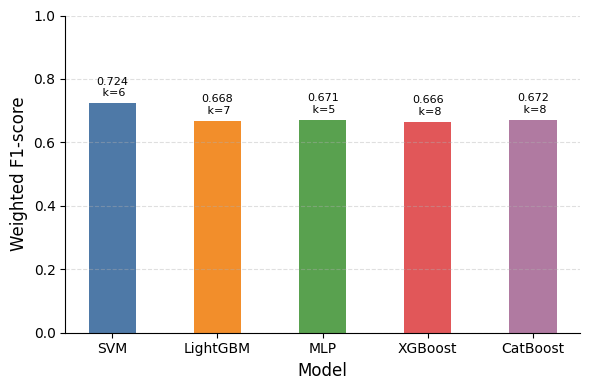

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results)

colors = [
    "#4E79A7",  # SVM
    "#F28E2B",  # LightGBM
    "#59A14F",  # MLP
    "#E15759",  # XGBoost
    "#B07AA1"   # CatBoost
]

plt.figure(figsize=(6, 4))

bars = plt.bar(
    df["model"],
    df["f1_score"],
    color=colors,
    width=0.45
)

plt.ylabel("Weighted F1-score", fontsize=12)
plt.xlabel("Model", fontsize=12)

plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Add score and configuration above each bar
for bar, row in zip(bars, df.itertuples()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        row.f1_score + 0.015,
        f"{row.f1_score:.3f}\n k={row.k}",
        ha="center",
        va="bottom",
        fontsize=8
    )

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()